# =============================================================================
# tDCBAM (PROPOSED) — TRAIN-VAL-TEST SPLIT EVALUATION
# =============================================================================
Evaluates the proposed **tDCBAM** model (DenseNet121 + CBAM + Triplet Network) on
per-dataset splits at configurable ratios (60:20:20, 65:18:18, 70:15:15).

Dataset: **CEDAR**

## How the 2-Step Process Maps to Standard Splits

For each dataset × split ratio (e.g., CEDAR 70:15:15):

| Step | Description | Data Used |
|------|-------------|-----------|
| **Step 1: Pretraining** | Train tDCBAM backbone with triplet loss | **Train users** (70%) |
| **Step 2: Meta-Training** | Train metric learning on top of pretrained backbone | **Train users** (70%)**Val users**(15%)|
| **Evaluation** | K-shot verification on unseen users | **Test users** (15%) |

The few-shot nature is preserved at test time: for each unseen test user,
K reference signatures (support set) are provided, and remaining signatures are classified.

**Prerequisites:** Run `scripts/prepare_split_ratios.py` to generate split JSONs.

# =============================================================================
# STEP 1: SETUP, IMPORTS, AND REPRODUCIBILITY
# =============================================================================

In [1]:
import os
import sys
import json
import random
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image

# Set repo root
current_dir = os.path.abspath(os.getcwd())
REPO_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

# Import Custom Modules
from models.feature_extractor import DenseNetFeatureExtractor
from models.meta_learner import MetricGenerator
from models.Triplet_Siamese_Similarity_Network import tDCBAM
from losses.triplet_loss import TripletLoss
from utils.model_evaluation import compute_metrics, _plot_det_curve, _plot_far_frr, _plot_confusion_matrix, _plot_score_distribution, _plot_roc_curve
from dataloader.tDCBAM_trainloader import get_pretraining_transforms

# Deterministic Seeding
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f" > [System] Seed set to: {seed}")

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [System] Device: {DEVICE}")
if torch.cuda.is_available():
    print(f" > [System] CUDA Device Name: {torch.cuda.get_device_name()}")

/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


 > [System] Seed set to: 42
 > [System] Device: cuda
 > [System] CUDA Device Name: NVIDIA GeForce RTX 5080


# =============================================================================
# STEP 2: CONFIGURATION
# =============================================================================

In [2]:
# -- Input Configuration --
IMG_SIZE = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE)

# -- Step 1: Pretraining Hyperparameters (Triplet Loss) --
PRETRAIN_BATCH_SIZE = 32
PRETRAIN_EPOCHS = 30
PRETRAIN_PHASE1_EPOCHS = 7   # Frozen backbone (CBAM-only)
PRETRAIN_LR = 1e-4
PRETRAIN_MARGIN = 1.0

# -- Step 2: Meta-Training Hyperparameters --
META_BATCH_SIZE = 16
META_EPOCHS = 70
META_PHASE1_EPOCHS = 20       # Frozen backbone
META_LR_PHASE1 = 1e-3
META_LR_BACKBONE = 1e-5
META_LR_HEAD = 2e-4

# Meta-learning protocol
K_SHOT = 1
N_QUERY_GENUINE = 1
N_QUERY_FORGERY = 1

# Model dimensions
FEATURE_DIM = 1024
EMBEDDING_DIM = 2048          # Concatenated: 1024 + 1024

# Preprocessing & Augmentation
PREPROCESS = True
AUGMENT = True

# -- Dataset & Split Ratios (now train:val:test) --
SPLIT_DIR = os.path.join(REPO_ROOT, 'data', 'ratio_splits')
DATASET = 'cedar'
DATASET_NAME = 'CEDAR'
SPLIT_RATIOS = ['65_18_18', '70_15_15', '60_20_20']

# -- Checkpoints --
CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'checkpoints', 'proposed_splits')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# -- Evaluation Output Directory --
NOTEBOOK_NAME = 'proposed_cedar'
EVAL_DIR = os.path.join(REPO_ROOT, 'model_evals', NOTEBOOK_NAME)
os.makedirs(EVAL_DIR, exist_ok=True)

print(f"[Config] Step 1 -- Pretraining: {PRETRAIN_EPOCHS} epochs, margin={PRETRAIN_MARGIN}")
print(f"[Config] Step 2 -- Meta-Training: {META_EPOCHS} epochs, K-shot={K_SHOT}")
print(f"[Config] Dataset: {DATASET_NAME}")
print(f"[Config] Splits: {SPLIT_RATIOS}")
print(f"[Config] Eval Dir: {EVAL_DIR}")


[Config] Step 1 -- Pretraining: 30 epochs, margin=1.0
[Config] Step 2 -- Meta-Training: 70 epochs, K-shot=1
[Config] Dataset: CEDAR
[Config] Splits: ['65_18_18', '70_15_15', '60_20_20']
[Config] Eval Dir: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar


# =============================================================================
# STEP 3: GENERATE SPLITS (if needed)
# =============================================================================

# =============================================================================
# STEP 4: DATASET CLASSES
# =============================================================================
Two dataset classes are needed:
1. **TripletDataset** — For Step 1 (pretraining with triplet loss)
2. **EpisodicDataset** — For Step 2 (meta-training with episodic protocol)

Both operate on the **train split** users only.

In [3]:
# ─────────────────────────────────────────────────────────────
# DATASET 1: Triplet Dataset for Step 1 (Pretraining)
# ─────────────────────────────────────────────────────────────

class SplitTripletDataset(Dataset):
    """
    Generates (Anchor, Positive, Negative) triplets from a user dictionary.
    Uses hard negative mining: 70% skilled forgeries, 30% random negatives.
    """
    def __init__(self, user_dict, transform=None):
        self.transform = transform
        self.user_genuine_map = {}
        self.user_forged_map = {}
        self.all_genuine_paths = []

        for uid, data in user_dict.items():
            gen_key = next((k for k in data.keys() if k.lower() in ['genuine', 'gen']), None)
            forg_key = next((k for k in data.keys() if k.lower() in ['forged', 'forgeries', 'forg']), None)
            
            gen_paths = data.get(gen_key, []) if gen_key else []
            forg_paths = data.get(forg_key, []) if forg_key else []
            
            if len(gen_paths) >= 2:
                self.user_genuine_map[uid] = gen_paths
                self.user_forged_map[uid] = forg_paths
                self.all_genuine_paths.extend([(p, uid) for p in gen_paths])
        
        self.users = list(self.user_genuine_map.keys())
        self.triplets = []
        self._generate_triplets()
        print(f"   TripletDataset: {len(self.triplets)} triplets from {len(self.users)} users")

    def _generate_triplets(self):
        """Regenerate triplets with hard negative mining."""
        self.triplets = []
        
        for anchor_path, anchor_uid in self.all_genuine_paths:
            positives = [p for p in self.user_genuine_map[anchor_uid] if p != anchor_path]
            if not positives:
                continue
            positive_path = random.choice(positives)
            
            # Hard mining: 70% skilled forgery, 30% random user
            forgeries = self.user_forged_map.get(anchor_uid, [])
            if random.random() < 0.7 and len(forgeries) > 0:
                negative_path = random.choice(forgeries)
            else:
                other_uid = random.choice([u for u in self.users if u != anchor_uid])
                negative_path = random.choice(self.user_genuine_map[other_uid])
            
            self.triplets.append((anchor_path, positive_path, negative_path))

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        anchor_p, pos_p, neg_p = self.triplets[idx]
        anchor = self._load(anchor_p)
        pos = self._load(pos_p)
        neg = self._load(neg_p)
        return anchor, pos, neg, torch.tensor([1], dtype=torch.float32)

    def _load(self, path):
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img


# ─────────────────────────────────────────────────────────────
# DATASET 2: Episodic Dataset for Step 2 (Metric Learning)
# ─────────────────────────────────────────────────────────────

class SplitEpisodicDataset(Dataset):
    """
    Generates episodes for metric learning from a user dictionary.
    Each episode: K support (genuine) + queries (genuine + forged).
    
    NOTE: This dataset now uses get_pretraining_transforms to ensure consistency
    with Step 1 pretraining. Both steps use the same preprocessing pipeline.
    """
    def __init__(self, user_dict, k_shot=1, n_query_genuine=1, n_query_forgery=1, 
                 augment=False, exhaustive_eval=False):
        self.k_shot = k_shot
        self.n_query_genuine = n_query_genuine
        self.n_query_forgery = n_query_forgery
        self.augment = augment
        self.exhaustive_eval = exhaustive_eval
        self.users = []
        self.data = {}
        
        # Use the same transforms as Step 1 for consistency
        # Support images: apply augmentation during training
        self.augment_transform = get_pretraining_transforms(
            input_shape=INPUT_SHAPE, 
            preprocess=PREPROCESS, 
            augment=True
        )
        
        # Query images: no augmentation (clean evaluation)
        self.base_transform = get_pretraining_transforms(
            input_shape=INPUT_SHAPE, 
            preprocess=PREPROCESS, 
            augment=False
        )
        
        for uid, udata in user_dict.items():
            gen_key = next((k for k in udata.keys() if k.lower() in ['genuine', 'gen']), None)
            forg_key = next((k for k in udata.keys() if k.lower() in ['forged', 'forgeries', 'forg']), None)
            
            gen_paths = udata.get(gen_key, []) if gen_key else []
            forg_paths = udata.get(forg_key, []) if forg_key else []
            
            if len(gen_paths) >= k_shot + n_query_genuine and len(forg_paths) >= n_query_forgery:
                self.users.append(uid)
                self.data[uid] = {'genuine': gen_paths, 'forged': forg_paths}
        
        print(f"   EpisodicDataset: {len(self.users)} users (K={k_shot}, Qg={n_query_genuine}, Qf={n_query_forgery})")

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        uid = self.users[idx]
        genuine_paths = self.data[uid]['genuine']
        forgery_paths = self.data[uid]['forged']
        
        # Sample support (K genuine)
        support_paths = random.sample(genuine_paths, self.k_shot)
        
        # Sample query genuine (from remaining)
        remaining_gen = [p for p in genuine_paths if p not in support_paths]
        if self.exhaustive_eval:
            query_gen_paths = remaining_gen
            query_forg_paths = forgery_paths
        else:
            if len(remaining_gen) < self.n_query_genuine:
                query_gen_paths = random.choices(genuine_paths, k=self.n_query_genuine)
            else:
                query_gen_paths = random.sample(remaining_gen, self.n_query_genuine)
            
            # Sample query forged
            if len(forgery_paths) < self.n_query_forgery:
                query_forg_paths = random.choices(forgery_paths, k=self.n_query_forgery)
            else:
                query_forg_paths = random.sample(forgery_paths, self.n_query_forgery)
        
        # Load images
        support_imgs = self._load_batch(support_paths, augment=self.augment)
        query_imgs_gen = self._load_batch(query_gen_paths, augment=False)
        query_imgs_forg = self._load_batch(query_forg_paths, augment=False)
        
        query_imgs = torch.cat([query_imgs_gen, query_imgs_forg], dim=0)
        labels_gen = torch.ones(len(query_imgs_gen), dtype=torch.float32)
        labels_forg = torch.zeros(len(query_imgs_forg), dtype=torch.float32)
        query_labels = torch.cat([labels_gen, labels_forg], dim=0)
        
        return {
            'support_images': support_imgs,
            'query_images': query_imgs,
            'query_labels': query_labels,
            'user_id': str(uid)
        }

    def _load_batch(self, paths, augment=False):
        images = []
        transform = self.augment_transform if augment else self.base_transform
        for path in paths:
            try:
                img = Image.open(path).convert('RGB')
                images.append(transform(img))
            except Exception:
                pass
        return torch.stack(images) if images else torch.empty(0)


print(" > Dataset classes defined (TripletDataset + EpisodicDataset)")

 > Dataset classes defined (TripletDataset + EpisodicDataset)


# =============================================================================
# STEP 5: STEP 1 — PRETRAINING ENGINE (Triplet Loss)
# =============================================================================
Trains the tDCBAM feature extractor backbone using triplet loss on the **train split** users.
This is the representation learning phase.

In [4]:
def run_pretraining(train_user_dict, device, checkpoint_path,
                    epochs=30, phase1_epochs=10, lr=1e-4, margin=2.0, batch_size=32):
    """
    Step 1: Pretrain tDCBAM with triplet loss on train-split users.
    
    Args:
        train_user_dict: {uid: {"genuine": [...], "forged": [...]}} for train users
        device: torch device
        checkpoint_path: where to save best weights
        
    Returns:
        Path to saved pretrained weights
    """
    print(f"\n   {'─'*50}")
    print(f"   STEP 1: PRETRAINING (Triplet Loss)")
    print(f"   Epochs: {epochs} (Phase1: {phase1_epochs} frozen)")
    print(f"   {'─'*50}")
    
    seed_everything(42)
    
    # Transform
    transform = get_pretraining_transforms(input_shape=INPUT_SHAPE, preprocess=PREPROCESS, augment=AUGMENT)
    
    # Dataset
    dataset = SplitTripletDataset(train_user_dict, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
    
    # Model
    model = tDCBAM(backbone_name='densenet121', output_dim=FEATURE_DIM, pretrained=True).to(device)
    criterion = TripletLoss(margin=margin)
    
    # Phase 1: Freeze backbone, train CBAM only
    fe = model.feature_extractor
    for module in [fe.initial_layers, fe.block1, fe.trans1, fe.block2, fe.trans2,
                   fe.block3, fe.trans3, fe.block4, fe.norm5]:
        for param in module.parameters():
            param.requires_grad = False
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"   Phase 1: {trainable:,}/{total:,} params trainable")
    
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    best_loss = float('inf')
    
    for epoch in range(epochs):
        # Phase transition
        if epoch == phase1_epochs:
            for param in model.parameters():
                param.requires_grad = True
            optimizer = optim.Adam(model.parameters(), lr=lr * 0.1)
            trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"   Phase 2: Unfrozen — {trainable:,} params trainable")
        
        model.train()
        epoch_loss = 0.0
        
        for anchor, pos, neg, _ in tqdm(loader, desc=f"Pretrain E{epoch+1}", leave=False):
            anchor, pos, neg = anchor.to(device), pos.to(device), neg.to(device)
            optimizer.zero_grad()
            a_feat, p_feat, n_feat = model(anchor, pos, neg)
            loss = criterion(a_feat, p_feat, n_feat)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(loader)
        phase = 1 if epoch < phase1_epochs else 2
        print(f"   [P{phase}] Epoch {epoch+1:02d}/{epochs} | Triplet Loss: {avg_loss:.4f}")
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.feature_extractor.state_dict(), checkpoint_path)
        
        # Regenerate triplets each epoch
        dataset._generate_triplets()
    
    print(f"   Pretraining complete. Best loss: {best_loss:.4f}")
    print(f"   Weights saved to: {os.path.basename(checkpoint_path)}")
    
    return checkpoint_path


print(" > Pretraining engine defined")

 > Pretraining engine defined


# =============================================================================
# STEP 6: STEP 2 — META-TRAINING ENGINE (Episodic Learning)
# =============================================================================
Trains the MetricGenerator on top of the pretrained feature extractor
using the **same train split** users with the episodic protocol.
Evaluates on the **test split** users.

In [5]:
def freeze_backbone(feature_extractor):
    """Freeze DenseNet backbone, keep CBAM + fc trainable."""
    for module in [feature_extractor.initial_layers,
                   feature_extractor.block1, feature_extractor.trans1,
                   feature_extractor.block2, feature_extractor.trans2,
                   feature_extractor.block3, feature_extractor.trans3,
                   feature_extractor.block4, feature_extractor.norm5]:
        for param in module.parameters():
            param.requires_grad = False


def unfreeze_backbone(feature_extractor):
    """Unfreeze all parameters."""
    for param in feature_extractor.parameters():
        param.requires_grad = True


def meta_train_epoch(fe, mg, loader, optimizer, criterion, device):
    """One epoch of episodic meta-training."""
    fe.train()
    mg.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for batch in tqdm(loader, desc="Meta-Train", leave=False):
        support_imgs = batch['support_images'].squeeze(1).to(device)
        query_imgs = batch['query_images'].to(device)
        labels = batch['query_labels'].to(device)
        
        B, N_Q, C, H, W = query_imgs.shape
        query_flat = query_imgs.view(B * N_Q, C, H, W)
        labels_flat = labels.view(B * N_Q).unsqueeze(1)
        support_flat = support_imgs.unsqueeze(1).expand(-1, N_Q, -1, -1, -1).reshape(B * N_Q, C, H, W)
        
        optimizer.zero_grad()
        s_feats = fe(support_flat)
        q_feats = fe(query_flat)
        combined = torch.cat((s_feats, q_feats), dim=1)
        scores = mg(combined)
        loss = criterion(scores, labels_flat)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = (torch.sigmoid(scores) > 0.5).float()
        correct += (preds == labels_flat).sum().item()
        total += labels_flat.size(0)
    
    return running_loss / len(loader), correct / total


def meta_validate(fe, mg, loader, device):
    """Validate meta-learner, compute metrics including EER."""
    fe.eval()
    mg.eval()
    all_labels, all_scores = [], []
    
    with torch.no_grad():
        for batch in loader:
            support_imgs = batch['support_images'].squeeze(1).to(device)
            query_imgs = batch['query_images'].to(device)
            labels = batch['query_labels'].to(device)
            
            B, N_Q, C, H, W = query_imgs.shape
            query_flat = query_imgs.view(B * N_Q, C, H, W)
            labels_flat = labels.view(B * N_Q).unsqueeze(1)
            support_flat = support_imgs.unsqueeze(1).expand(-1, N_Q, -1, -1, -1).reshape(B * N_Q, C, H, W)
            
            s_feats = fe(support_flat)
            q_feats = fe(query_flat)
            combined = torch.cat((s_feats, q_feats), dim=1)
            scores = mg(combined)
            probs = torch.sigmoid(scores)
            
            all_scores.extend(probs.cpu().numpy().flatten())
            all_labels.extend(labels_flat.cpu().numpy().flatten())
    
    return compute_metrics(all_labels, all_scores)


def evaluate_model(fe, mg, loader, device, output_dir=None, silent=False):
    """Evaluate meta-learner and compute metrics including EER, with optional reporting."""
    metrics = meta_validate(fe, mg, loader, device)
    
    if output_dir and not silent:
        # Full Reporting
        print(f"\n{'='*10} FINAL TEST RESULTS {'='*10}")
        print(f"EER            : {metrics['eer']:.2%}")
        print(f"AUC            : {metrics['auc']:.4f}")
        print(f"Best Threshold : {metrics.get('threshold', 0):.4f}")
        print(f"Accuracy       : {metrics['accuracy']:.2%}")
        print(f"Precision      : {metrics.get('precision', 0):.2%}")
        print(f"Recall         : {metrics['recall']:.2%}")
        print(f"F1-Score       : {metrics.get('f1', 0):.2%}")
        print("="*40)
        
        _plot_roc_curve(metrics, output_dir)
        _plot_score_distribution(metrics, output_dir)
        _plot_confusion_matrix(metrics, output_dir)
        _plot_det_curve(metrics, output_dir)
        _plot_far_frr(metrics, output_dir)
    
    return metrics


def run_meta_training(train_user_dict, val_user_dict, test_user_dict, pretrained_path, device, checkpoint_path,
                      epochs=70, phase1_epochs=15, lr_phase1=1e-3, 
                      lr_backbone=1e-5, lr_head=1e-4, batch_size=16, output_dir=None):
    """
    Step 2: Meta-train MetricGenerator using episodic protocol.
    Train-Val-Test strategy: Train on train, validate on val for model selection, test for final evaluation only.
    
    Args:
        train_user_dict: Train split users (for episodic training)
        val_user_dict: Validation split users (for model selection)
        test_user_dict: Test split users (NEVER seen during training, final evaluation only)  
        pretrained_path: Path to Step 1 pretrained weights
        device: torch device
        checkpoint_path: where to save best model
        output_dir: directory for evaluation plots
    
    Returns:
        Best metrics dict (from final test evaluation)
    """
    print(f"\n   {'-'*50}")
    print(f"   STEP 2: META-TRAINING (Episodic Learning)")
    print(f"   Epochs: {epochs} (Phase1: {phase1_epochs} frozen)")
    print(f"   {'-'*50}")
    
    # Datasets - NO test_loader during training, only for final evaluation
    train_set = SplitEpisodicDataset(train_user_dict, k_shot=K_SHOT, 
                                      n_query_genuine=N_QUERY_GENUINE, 
                                      n_query_forgery=N_QUERY_FORGERY, augment=True)
    val_set = SplitEpisodicDataset(val_user_dict, k_shot=K_SHOT,
                                    n_query_genuine=N_QUERY_GENUINE,
                                    n_query_forgery=N_QUERY_FORGERY, augment=False)
    test_set = SplitEpisodicDataset(test_user_dict, k_shot=K_SHOT,
                                     n_query_genuine=N_QUERY_GENUINE,
                                     n_query_forgery=N_QUERY_FORGERY, augment=False, exhaustive_eval=True)
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    
    # Initialize models
    fe = DenseNetFeatureExtractor(backbone_name='densenet121', output_dim=FEATURE_DIM).to(device)
    mg = MetricGenerator(embedding_dim=EMBEDDING_DIM).to(device)
    
    # Load pretrained weights from Step 1
    if os.path.exists(pretrained_path):
        state = torch.load(pretrained_path, map_location=device, weights_only=False)
        if isinstance(state, dict) and 'state_dict' in state:
            state = state['state_dict']
        # Strip 'feature_extractor.' prefix if present
        clean_state = {}
        for k, v in state.items():
            new_k = k.replace('feature_extractor.', '', 1) if k.startswith('feature_extractor.') else k
            clean_state[new_k] = v
        try:
            fe.load_state_dict(clean_state, strict=True)
            print(f"   Loaded pretrained weights (strict)")
        except RuntimeError:
            fe.load_state_dict(clean_state, strict=False)
            print(f"   Loaded pretrained weights (partial)")
    else:
        print(f"   WARNING: No pretrained weights found, using ImageNet init")
    
    criterion = nn.BCEWithLogitsLoss()
    best_eer, best_acc, best_metrics = 1.0, 0.0, {}
    
    # -- Phase 1: Frozen backbone, train on train, validate on val --
    freeze_backbone(fe)
    optimizer = optim.AdamW([
        {'params': filter(lambda p: p.requires_grad, fe.parameters()), 'lr': lr_phase1},
        {'params': mg.parameters(), 'lr': lr_phase1}
    ], weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=8)
    
    for epoch in range(phase1_epochs):
        train_loss, train_acc = meta_train_epoch(fe, mg, train_loader, optimizer, criterion, device)
        val_metrics = meta_validate(fe, mg, val_loader, device)
        val_eer, val_acc = val_metrics['eer'], val_metrics['accuracy']
        
        print(f"   [P1] Epoch {epoch+1:02d}/{phase1_epochs} | Loss: {train_loss:.4f} | "
              f"Acc: {train_acc:.2%} | Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
        scheduler.step(val_eer)
        
        if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_metrics
            torch.save({
                'feature_extractor': fe.state_dict(),
                'metric_generator': mg.state_dict(),
                'metrics': {k: float(v) for k, v in val_metrics.items() if isinstance(v, (int, float, np.floating))}
            }, checkpoint_path)
            print(f"   >>> Saved! (EER: {val_eer:.2%})")
    
    # -- Phase 2: Unfreeze backbone, differential LR --
    unfreeze_backbone(fe)
    optimizer = optim.AdamW([
        {'params': fe.initial_layers.parameters(), 'lr': lr_backbone},
        {'params': fe.block1.parameters(), 'lr': lr_backbone},
        {'params': fe.trans1.parameters(), 'lr': lr_backbone},
        {'params': fe.block2.parameters(), 'lr': lr_backbone},
        {'params': fe.trans2.parameters(), 'lr': lr_backbone},
        {'params': fe.block3.parameters(), 'lr': lr_backbone},
        {'params': fe.trans3.parameters(), 'lr': lr_backbone},
        {'params': fe.block4.parameters(), 'lr': lr_backbone},
        {'params': fe.norm5.parameters(), 'lr': lr_backbone},
        {'params': fe.cbam1.parameters(), 'lr': lr_head},
        {'params': fe.cbam2.parameters(), 'lr': lr_head},
        {'params': fe.cbam3.parameters(), 'lr': lr_head},
        {'params': fe.cbam4.parameters(), 'lr': lr_head},
        {'params': fe.regularized_dense_block.parameters(), 'lr': lr_head},
        {'params': mg.parameters(), 'lr': lr_head}
    ], weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=8)
    
    phase2_epochs = epochs - phase1_epochs
    
    for epoch in range(phase2_epochs):
        train_loss, train_acc = meta_train_epoch(fe, mg, train_loader, optimizer, criterion, device)
        val_metrics = meta_validate(fe, mg, val_loader, device)
        val_eer, val_acc = val_metrics['eer'], val_metrics['accuracy']
        
        g_epoch = phase1_epochs + epoch + 1
        print(f"   [P2] Epoch {epoch+1:02d}/{phase2_epochs} (G:{g_epoch}) | Loss: {train_loss:.4f} | "
              f"Acc: {train_acc:.2%} | Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
        scheduler.step(val_eer)
        
        if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_metrics
            torch.save({
                'feature_extractor': fe.state_dict(),
                'metric_generator': mg.state_dict(),
                'metrics': {k: float(v) for k, v in val_metrics.items() if isinstance(v, (int, float, np.floating))}
            }, checkpoint_path)
            print(f"   >>> Saved! (EER: {val_eer:.2%})")
    
    # Final evaluation on test set (NEVER seen during training)
    final_metrics = best_metrics
    if output_dir:
        if os.path.exists(checkpoint_path):
            checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
            if isinstance(checkpoint, dict) and 'feature_extractor' in checkpoint:
                fe.load_state_dict(checkpoint['feature_extractor'], strict=True)
                mg.load_state_dict(checkpoint['metric_generator'], strict=True)
        final_metrics = evaluate_model(fe, mg, test_loader, device, output_dir=output_dir, silent=False)
    
    print(f"   Meta-training complete. Best Val EER: {best_eer:.2%}")
    return final_metrics


print(" > Meta-training engine defined")


 > Meta-training engine defined


# =============================================================================
# STEP 7: RUN ALL SPLIT RATIOS
# =============================================================================
For each split_ratio:
1. Load split JSON → get train/test user dicts
2. **Step 1**: Pretrain tDCBAM backbone with triplet loss on train users
3. **Step 2**: Meta-train MetricGenerator on train users, evaluate on test users

In [6]:
all_results = {}

for ratio in SPLIT_RATIOS:
    split_file = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    train_pct, val_pct, test_pct = ratio.split('_')
    split_eval_dir = os.path.join(EVAL_DIR, f"{NOTEBOOK_NAME}_{train_pct}-{val_pct}-{test_pct}")
    os.makedirs(split_eval_dir, exist_ok=True)
    
    print(f"\n{'='*70}")
    print(f" {DATASET_NAME} -- {train_pct}:{val_pct}:{test_pct} Split (PROPOSED tDCBAM)")
    print(f"{'='*70}")
    
    if not os.path.exists(split_file):
        print(f"   SKIPPED: {split_file} not found")
        continue
    
    with open(split_file, 'r') as f:
        split_data = json.load(f)
    
    train_dict = split_data['train']
    val_dict = split_data['val']
    test_dict = split_data['test']
    
    print(f"   Train users: {len(train_dict)} | Val users: {len(val_dict)} | Test users: {len(test_dict)}")
    
    # Create experiment checkpoint dir
    exp_dir = os.path.join(CHECKPOINT_DIR, f"{DATASET}_{ratio}")
    os.makedirs(exp_dir, exist_ok=True)
    
    # -- STEP 1: Pretrain backbone on train users only --
    seed_everything(42)
    pretrain_path = os.path.join(exp_dir, "pretrained_backbone.pth")
    
    run_pretraining(
        train_user_dict=train_dict,
        device=DEVICE,
        checkpoint_path=pretrain_path,
        epochs=PRETRAIN_EPOCHS,
        phase1_epochs=PRETRAIN_PHASE1_EPOCHS,
        lr=PRETRAIN_LR,
        margin=PRETRAIN_MARGIN,
        batch_size=PRETRAIN_BATCH_SIZE
    )
    
    # -- STEP 2: Meta-train on train, validate on val, test on test (final only) --
    seed_everything(42)
    meta_ckpt_path = os.path.join(exp_dir, "best_meta_model.pth")
    
    best_metrics = run_meta_training(
        train_user_dict=train_dict,
        val_user_dict=val_dict,
        test_user_dict=test_dict,
        pretrained_path=pretrain_path,
        device=DEVICE,
        checkpoint_path=meta_ckpt_path,
        epochs=META_EPOCHS,
        phase1_epochs=META_PHASE1_EPOCHS,
        lr_phase1=META_LR_PHASE1,
        lr_backbone=META_LR_BACKBONE,
        lr_head=META_LR_HEAD,
        batch_size=META_BATCH_SIZE,
        output_dir=split_eval_dir
    )
    
    # -- Record Results --
    result_key = f"{DATASET_NAME} ({train_pct}:{val_pct}:{test_pct})"
    all_results[result_key] = {
        'dataset': DATASET_NAME,
        'split': f"{train_pct}:{val_pct}:{test_pct}",
        'train_users': len(train_dict),
        'val_users': len(val_dict),
        'test_users': len(test_dict),
        'eer': float(best_metrics['eer']),
        'accuracy': float(best_metrics['accuracy']),
        'auc': float(best_metrics['auc']),
        'precision': float(best_metrics['precision']),
        'recall': float(best_metrics['recall']),
        'f1': float(best_metrics['f1'])
    }
    
    print(f"\n   FINAL TEST RESULT: EER={best_metrics['eer']:.2%} | Acc={best_metrics['accuracy']:.2%} | "
          f"AUC={best_metrics['auc']:.4f} | F1={best_metrics['f1']:.4f}")

print(f"\n{'='*70}")
print("ALL EXPERIMENTS COMPLETE")
print(f"{'='*70}")



 CEDAR -- 65:18:18 Split (PROPOSED tDCBAM)
   Train users: 35 | Val users: 9 | Test users: 11
 > [System] Seed set to: 42

   ──────────────────────────────────────────────────
   STEP 1: PRETRAINING (Triplet Loss)
   Epochs: 30 (Phase1: 7 frozen)
   ──────────────────────────────────────────────────
 > [System] Seed set to: 42
   TripletDataset: 840 triplets from 35 users
   Phase 1: 1,139,080/8,092,936 params trainable


Pretrain E1:   0%|          | 0/26 [00:00<?, ?it/s]

   [P1] Epoch 01/30 | Triplet Loss: 2.3802


Pretrain E2:   0%|          | 0/26 [00:00<?, ?it/s]

   [P1] Epoch 02/30 | Triplet Loss: 2.2780


...

   [P2] Epoch 48/50 (G:68) | Loss: 0.2531 | Acc: 90.91% | Val EER: 36.36% | Val Acc: 63.64%


Meta-Train:   0%|          | 0/3 [00:00<?, ?it/s]

   [P2] Epoch 49/50 (G:69) | Loss: 0.2756 | Acc: 83.33% | Val EER: 18.18% | Val Acc: 81.82%


Meta-Train:   0%|          | 0/3 [00:00<?, ?it/s]

   [P2] Epoch 50/50 (G:70) | Loss: 0.2503 | Acc: 86.36% | Val EER: 9.09% | Val Acc: 90.91%

========== FINAL TEST RESULTS ==========
EER            : 22.73%
AUC            : 0.8545
Best Threshold : 0.3814
Accuracy       : 77.37%
Precision      : 76.56%
Recall         : 77.47%
F1-Score       : 77.01%
 > Saved ROC Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_60-20-20/roc_curve.png
 > Saved Distribution Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_60-20-20/score_distribution.png
 > Saved Confusion Matrix to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_60-20-20/confusion_matrix.png
 > Saved DET Curve to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_60-20-20/det_curve.png
 > Saved FAR/FRR Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_60-20-20/far_frr.png
   Meta-training complete. Best V

# =============================================================================
# STEP 8: SUMMARY TABLE
# =============================================================================

In [7]:
# Print summary table
print(f"\n{'='*80}")
print(f"{'PROPOSED tDCBAM — ' + DATASET_NAME + ' SPLIT EVALUATION':^80}")
print(f"{'='*80}")
print(f"{'Split':<10} {'Train':<8} {'Val':<8} {'Test':<8} {'EER':<10} {'Accuracy':<10} {'AUC':<10} {'F1':<10}")
print(f"{'-'*80}")

for key, res in all_results.items():
    print(f"{res['split']:<10} {res['train_users']:<8} {res['val_users']:<8} {res['test_users']:<8} "
          f"{res['eer']:.4f}    {res['accuracy']:.4f}    {res['auc']:.4f}    {res['f1']:.4f}")

print(f"{'='*80}")

# Save results
results_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"\n > Results saved to: {results_path}")


                    PROPOSED tDCBAM — CEDAR SPLIT EVALUATION                    
Split      Train    Val      Test     EER        Accuracy   AUC        F1        
--------------------------------------------------------------------------------
65:18:18   35       9        11       0.1780    0.8201    0.8739    0.8166
70:15:15   38       8        9        0.1620    0.8416    0.9226    0.8393
60:20:20   33       11       11       0.2273    0.7737    0.8545    0.7701

 > Results saved to: /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_cedar_results.json


# =============================================================================
# STEP 9: VISUALIZATION
# =============================================================================

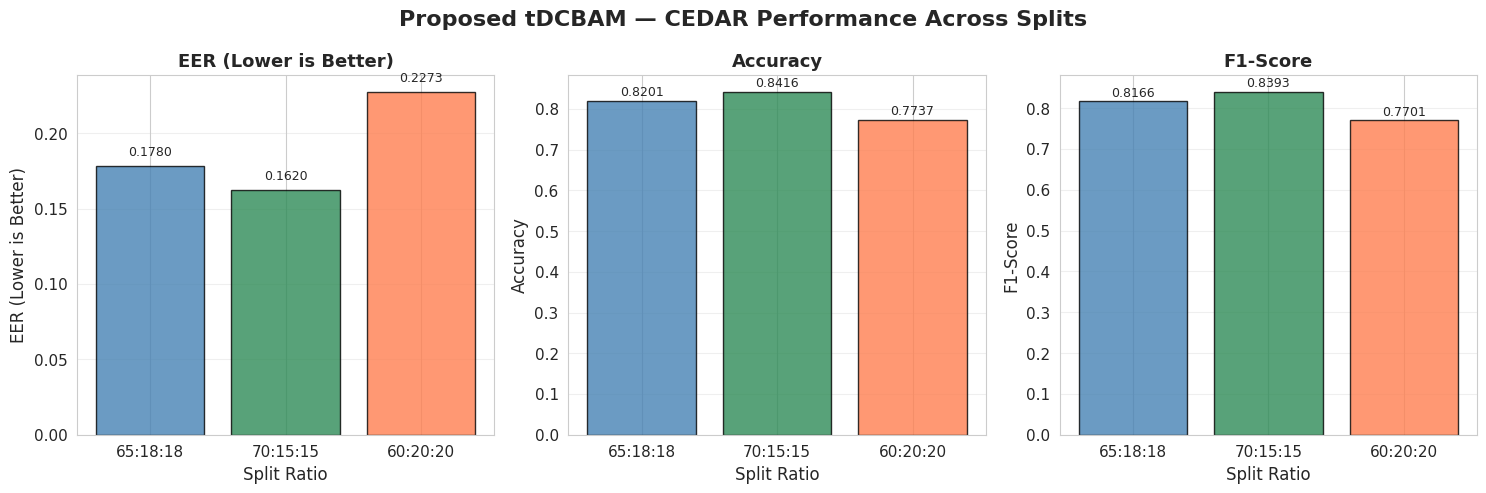

 > Plot saved to: /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_cedar_comparison.png


In [8]:
# Bar chart: Metrics by split ratio
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Proposed tDCBAM — {DATASET_NAME} Performance Across Splits', fontsize=16, fontweight='bold')

metrics_to_plot = ['eer', 'accuracy', 'f1']
titles = ['EER (Lower is Better)', 'Accuracy', 'F1-Score']
colors = ['steelblue', 'seagreen', 'coral']

for ax_idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[ax_idx]
    split_labels = []
    values = []
    
    for ratio in SPLIT_RATIOS:
        split_str = ratio.replace('_', ':')
        split_labels.append(split_str)
        key = f"{DATASET_NAME} ({split_str})"
        values.append(all_results.get(key, {}).get(metric, 0))
    
    bars = ax.bar(split_labels, values, color=colors, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=12)
    ax.set_ylabel(title, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved to: {plot_path}")